In [ ]:
%pip install seaborn

In [10]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
import numpy as np
import matplotlib.pyplot as plt


# Step 1: Load the data
df = pd.read_csv('./data/car_price_dataset.csv')

df.head()
# df.describe()

,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


In [2]:
df.describe()

,Year,Engine_Size,Mileage,Doors,Owner_Count,Price
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,2011.544900,3.000560,149239.111800,3.497100,2.991100,8852.96440
std,6.897952,1.149324,86322.348957,1.110097,1.422682,3112.59681
min,2000.000000,1.000000,25.000000,2.000000,1.000000,2000.00000
25%,2006.000000,2.000000,74649.250000,3.000000,2.000000,6646.00000
50%,2012.000000,3.000000,149587.000000,3.000000,3.000000,8858.50000
75%,2017.000000,4.000000,223577.500000,4.000000,4.000000,11086.50000
max,2023.000000,5.000000,299947.000000,5.000000,5.000000,18301.00000


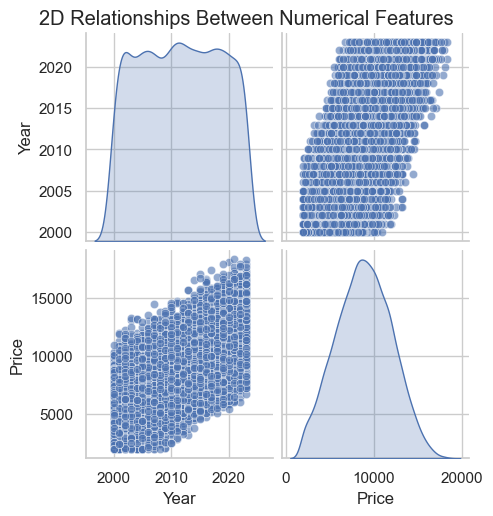

In [13]:
# Set aesthetic style
sns.set(style="whitegrid")

# Focus on a few selected numerical columns for pairplot
num_features = ['Year','Price']

# Plot pairplot for numerical columns
sns.pairplot(df[num_features], diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle("2D Relationships Between Numerical Features", y=1.02)
plt.show()

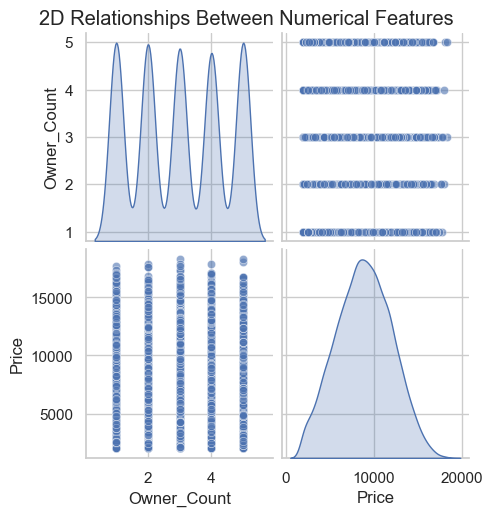

In [15]:
# Set aesthetic style
sns.set(style="whitegrid")

# Focus on a few selected numerical columns for pairplot
num_features = ['Owner_Count','Price']

# Plot pairplot for numerical columns
sns.pairplot(df[num_features], diag_kind='kde', plot_kws={'alpha':0.6})
plt.suptitle("2D Relationships Between Numerical Features", y=1.02)
plt.show()

In [46]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import DBSCAN
from scipy.spatial.distance import cdist
import pandas as pd
import numpy as np

def find_closest_match(data, user_input):
    numeric = ['Year', 'Engine_Size', 'Mileage', 'Doors', 'Owner_Count', 'Price']
    categorical = ['Brand', 'Model', 'Fuel_Type', 'Transmission']

    # Split input into numeric/categorical
    input_numeric = {k: v for k, v in user_input.items() if k in numeric}
    input_categorical = {k: v for k, v in user_input.items() if k in categorical}

    # Filter dataset by only selected features
    features = pd.DataFrame()
    input_vector = pd.DataFrame()

    # Handle numeric
    if input_numeric:
        features = data[list(input_numeric.keys())].copy()
        input_vector = pd.DataFrame([input_numeric])

        scaler = StandardScaler()
        features_scaled = scaler.fit_transform(features)
        input_scaled = scaler.transform(input_vector)

        features = pd.DataFrame(features_scaled, columns=input_numeric.keys())
        input_vector = pd.DataFrame(input_scaled, columns=input_numeric.keys())

    # Handle categorical
    if input_categorical:
        cat_df = data[list(input_categorical.keys())].copy()
        input_cat_df = pd.DataFrame([input_categorical])

        encoder = OneHotEncoder(handle_unknown='ignore', sparse=False)
        encoded = encoder.fit_transform(cat_df)
        input_encoded = encoder.transform(input_cat_df)

        # cat_feature_names = encoder.get_feature_names_out(input_categorical.keys())
        cat_feature_names = encoder.get_feature_names_out(cat_df.columns)

        encoded_df = pd.DataFrame(encoded, columns=cat_feature_names)
        input_encoded_df = pd.DataFrame(input_encoded, columns=cat_feature_names)

        # Combine with numeric
        features = pd.concat([features.reset_index(drop=True), encoded_df.reset_index(drop=True)], axis=1)
        input_vector = pd.concat([input_vector.reset_index(drop=True), input_encoded_df.reset_index(drop=True)], axis=1)

    # Run DBSCAN on full dataset for context
    full_features = data[numeric + categorical]
    full_features_encoded = pd.get_dummies(full_features, drop_first=True)
    scaler_full = StandardScaler()
    full_scaled = scaler_full.fit_transform(full_features_encoded)

    db = DBSCAN(eps=3, min_samples=4, metric='euclidean')
    clusters = db.fit_predict(full_scaled)
    data['cluster'] = clusters
    # print(data[0:100])

    # Now compute distance in reduced (input-based) space
    # Make sure the feature set in input_vector matches feature columns
    cluster_label = clusters[np.argmin(cdist(features.values, input_vector.values))]
    print('++printing cluster', cluster_label)
    
    cluster_indices = data[data['cluster'] == cluster_label].index
    print('++index of cluster\n', cluster_indices)
    cluster_subset = features.iloc[cluster_indices]
    print('++cluster subset\n', cluster_subset)
    # compare distance between each pair of rows from two datasets
    dists = cdist(cluster_subset.values, input_vector.values)
    closest_index = cluster_indices[np.argmin(dists)]

    return data.loc[closest_index]


user_input = {
    "Brand": "Volkswagen",
    "Model": "Golf",
    "Year": 2021,
    "Engine_Size": 1.4,
    "Fuel_Type": "Petrol",
    "Transmission": "Automatic",
    "Mileage": 64978,
    "Doors": 5,
    "Owner_Count": 2,
    "Price": 12000,
    "cluster": 4
}

closest_car = find_closest_match(df, user_input)
print(closest_car)

/Users/dinachat/miniforge3/lib/python3.10/site-packages/sklearn/preprocessing/_encoders.py:975: FutureWarning: `sparse` was renamed to `sparse_output` in version 1.2 and will be removed in 1.4. `sparse_output` is ignored unless you leave `sparse` to its default value.
  warnings.warn(


++printing cluster 4
++index of cluster
 Index([   4,   11,   14,   15,   66,   79,  120,  134,  178,  195,
       ...
       9658, 9675, 9682, 9715, 9817, 9842, 9864, 9868, 9949, 9976],
      dtype='int64', length=339)
++cluster subset
           Year  Engine_Size   Mileage     Doors  Owner_Count     Price  \
4    -1.238821    -0.348535  1.591543 -0.447821     0.006256 -1.923238   
11   -0.368954     1.304693 -1.233162  0.453046     0.006256  0.832477   
14   -1.238821    -0.522559 -0.038441  1.353914    -0.696677 -0.922737   
15   -0.658910     0.173537 -1.032648 -1.348689    -1.399610  0.271181   
66   -1.673754     0.869633  1.019403  0.453046     1.412122 -1.445156   
...        ...          ...       ...       ...          ...       ...   
9842 -1.238821    -1.740728 -0.661624  0.453046     0.006256 -0.705544   
9864 -1.383799     1.652741 -1.127680 -0.447821    -0.696677 -0.093484   
9868 -1.238821    -0.957619  0.560044  1.353914     1.412122 -1.897213   
9949  0.790868     1.6